![image.png](https://i.imgur.com/a3uAqnb.png)
# Lab 8: Inference Optimisation

This notebook covers **LLM inference efficiency** — quantization, distillation, and benchmarking latency/memory trade-offs.

You will quantize **trained** model weights, compare **FP32 vs FP16 vs INT8** latency, distill a student from a **trained teacher on MNIST**, and measure **FP16 vs 4-bit VRAM**.

> 💡 Production deployment combines **multiple** techniques (quantization + distillation + KV cache). This lab isolates each lever with measurable comparisons.

__Install packages, then run cells in order.__

# 📦 Installing Required Python Libraries

This cell installs packages needed for this lab.

- **PyTorch** — Quantization helpers and micro-benchmarks.
- **Transformers / Bitsandbytes** — 4-bit model loading on GPU.
- **Matplotlib / NumPy** — Latency and error plots.


In [1]:
!pip install -q torch transformers accelerate bitsandbytes matplotlib numpy scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.5 MB/s eta 0:00:00


# 📥 Importing Essential Python Libraries

Imports for quantization, benchmarking, and distillation exercises.


In [2]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()} | device={DEVICE}")

PyTorch 2.11.0+cu128
CUDA available: True | device=cuda


__Theory first — connect definitions to the lecture slides, then move to code.__

---

## 🧠 Part A — Theory

*Reference: LLM inference bottlenecks, distillation, quantization, TurboQuant.*

### 📖 A1. Inference bottlenecks

1. During autoregressive decoding, is compute or memory usually the limit — and why?
2. How does **KV cache** size grow with context length $L$, layers, and heads?
3. Explain the differences between the **prefill** and **decode** phases.

*Write below:*


#### ✍️ Your answers (A1):

1. At long context / batch-1 decode, **memory bandwidth** (moving weights + KV cache) is usually the bottleneck, not peak FLOPs — decode is **memory-bound**.

2. KV cache size scales as $\mathcal{O}(L \times \text{layers} \times \text{heads} \times d_{\text{head}})$ per batch item — **linear in context length**.

3. **Prefill phase:** This is when the model processes the initial prompt. It involves computing the attention and feed-forward networks for all tokens in the prompt in parallel. The goal is to generate the initial KV cache entries for the prompt tokens. It is typically compute-bound.

**Decode phase:** This is the iterative process of generating one new token at a time. For each new token, the model uses the previously computed KV cache entries and processes only the newly generated token to predict the next one. This phase is usually memory-bound due to repeatedly accessing and updating the KV cache.

### 📖 A2. Compression methods

1. Contrast **knowledge distillation** vs **quantization** (what each compresses, typical accuracy trade-off).
2. Explain **per-tensor** vs **per-channel** weight quantization.
3. What problem does **TurboQuant** (lecture) target beyond vanilla INT4?

*Write below:*


#### ✍️ Your answers (A2):

1. **Distillation** transfers **behavior** from teacher to smaller student (architecture compression). **Quantization** reduces **weight/activation bit-width**. Distillation may preserve accuracy with fewer params; INT8/INT4 can be **fast** but risks **calibration error**.

2. **Per-tensor:** one scale for entire weight tensor (simple, coarser). **Per-channel:** scale per output channel (finer, better for CNNs/linear layers).

3. **TurboQuant** targets **outlier channels** and **activation distribution mismatch** that break naive INT4 — improving **accuracy at aggressive bit-widths**.

---

## 💻 Part B — Programming
__Let's implement the core ideas in PyTorch.__

*Reference: `New-Lecture-Inference_Optimisation.tex` — quantization, distillation, prefill vs decode.*

### 🛠️ B1. INT8 symmetric quantization on trained weights

We train a tiny **MNIST** classifier, quantize its first linear layer, and report both **weight error** and **test accuracy** before/after quantization.

In [3]:
def quantize_symmetric(w: torch.Tensor, bits: int = 8):
    """Return (w_q, scale) using symmetric per-tensor quantization."""
    qmax = 2 ** (bits - 1) - 1
    scale = w.abs().max().clamp(min=1e-8) / qmax
    w_q = torch.round(w / scale).clamp(-qmax, qmax).to(torch.int8)
    return w_q, scale


def dequantize(w_q, scale):
    return w_q.float() * scale


def eval_accuracy(model: nn.Module, loader) -> float:
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total


class TinyMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc2(F.relu(self.fc1(x)))


# Train a small classifier so we quantize real weights (not randn)
transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform),
    batch_size=128,
    shuffle=True,
)
test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform),
    batch_size=256,
    shuffle=False,
)

quant_model = TinyMNIST().to(DEVICE)
opt = torch.optim.Adam(quant_model.parameters(), lr=1e-3)
quant_model.train()
for epoch in range(2):
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        F.cross_entropy(quant_model(x), y).backward()
        opt.step()

fp32_acc = eval_accuracy(quant_model, test_loader)
w = quant_model.fc1.weight.data.detach().cpu()
wq, scale = quantize_symmetric(w)
w_hat = dequantize(wq, scale)
rel_err = (w - w_hat).norm() / w.norm()

# Swap in quantized fc1 weights and measure downstream accuracy
with torch.no_grad():
    quant_model.fc1.weight.copy_(w_hat.to(DEVICE))
quant_acc = eval_accuracy(quant_model, test_loader)

print(f"FC1 weight relative error: {rel_err.item():.4f}")
print(f"Test accuracy FP32 weights: {fp32_acc:.3f} | after INT8 dequant: {quant_acc:.3f}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 466kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.36MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.65MB/s]


FC1 weight relative error: 0.0147
Test accuracy FP32 weights: 0.950 | after INT8 dequant: 0.950


### 🛠️ B2. Benchmark linear forward pass (FP32 vs FP16 vs INT8)

Compare **FP32, FP16, and INT8 (dequant matmul)** latency on the same linear layer shape with a bar chart.

FP32 linear 1024->1024: 0.473 ms/forward
FP16 linear 1024->1024: 0.081 ms/forward
INT8 (dequant matmul) linear 1024->1024: 0.473 ms/forward


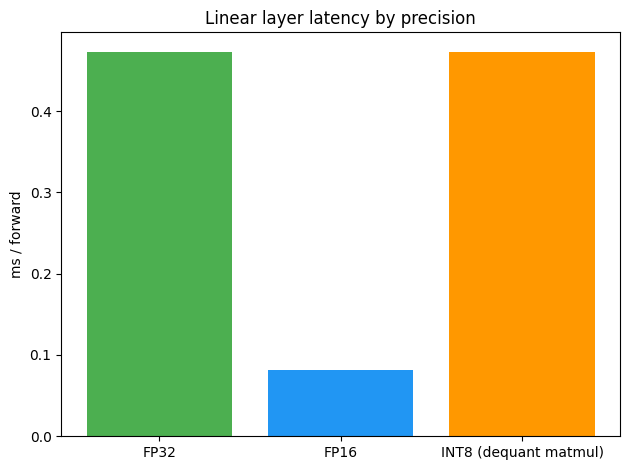

In [4]:
def bench_linear(in_features, out_features, dtype=torch.float32, n_warmup=10, n_iter=50):
    if dtype == torch.int8:
        raise ValueError("Use bench_linear_int8 for INT8")
    device = DEVICE
    x = torch.randn(1, 512, in_features, device=device, dtype=dtype if dtype != torch.int8 else torch.float32)
    layer = nn.Linear(in_features, out_features, bias=False).to(device)
    layer = layer.to(dtype if dtype != torch.int8 else torch.float32)
    for _ in range(n_warmup):
        layer(x)
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_iter):
        layer(x)
    if device == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n_iter * 1000


def bench_linear_int8(in_features, out_features, n_warmup=10, n_iter=50):
    device = DEVICE
    x = torch.randn(1, 512, in_features, device=device)
    w_fp = torch.randn(out_features, in_features, device=device)
    wq, scale = quantize_symmetric(w_fp.cpu())
    w_deq = dequantize(wq, scale).to(device)
    layer = nn.Linear(in_features, out_features, bias=False).to(device)
    layer.weight.data = w_deq
    for _ in range(n_warmup):
        layer(x)
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_iter):
        layer(x)
    if device == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n_iter * 1000


results = {"FP32": bench_linear(1024, 1024, torch.float32)}
if DEVICE == "cuda":
    results["FP16"] = bench_linear(1024, 1024, torch.float16)
results["INT8 (dequant matmul)"] = bench_linear_int8(1024, 1024)

for name, ms in results.items():
    print(f"{name} linear 1024->1024: {ms:.3f} ms/forward")

plt.bar(list(results.keys()), list(results.values()), color=["#4caf50", "#2196f3", "#ff9800"][: len(results)])
plt.ylabel("ms / forward")
plt.title("Linear layer latency by precision")
plt.tight_layout()
plt.show()

### 🛠️ B3. Knowledge distillation on MNIST

Train a **teacher** on MNIST, then compare a **student baseline** (CE only) vs a **distilled student** (KL + CE) using the trained teacher's soft targets.

Teacher test accuracy:          0.939
Student baseline (no distill):  0.922
Student distilled:              0.918


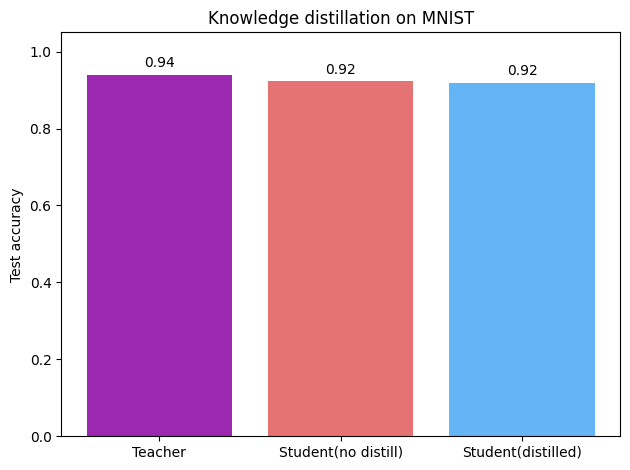

In [6]:
class Teacher(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))


class Student(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 64), nn.ReLU(), nn.Linear(64, 10))

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))


def train_ce(model, loader, steps=300):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    it = iter(loader)
    for _ in range(steps):
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(loader)
            x, y = next(it)
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        F.cross_entropy(model(x), y).backward()
        opt.step()


# 1) Train teacher on real MNIST
teacher = Teacher().to(DEVICE)
train_ce(teacher, train_loader, steps=400)
teacher_acc = eval_accuracy(teacher, test_loader)

# 2) Student baseline (no distillation)
student_base = Student().to(DEVICE)
train_ce(student_base, train_loader, steps=400)
base_acc = eval_accuracy(student_base, test_loader)

# 3) Distilled student from trained teacher
student = Student().to(DEVICE)
teacher.eval()
opt = torch.optim.Adam(student.parameters(), lr=1e-3)
T = 2.0
it = iter(train_loader)
student.train()
for _ in range(400):
    try:
        x, y = next(it)
    except StopIteration:
        it = iter(train_loader)
        x, y = next(it)
    x, y = x.to(DEVICE), y.to(DEVICE)
    with torch.no_grad():
        t_logits = teacher(x)
    s_logits = student(x)
    kl = F.kl_div(
        F.log_softmax(s_logits / T, dim=-1),
        F.softmax(t_logits / T, dim=-1),
        reduction="batchmean",
    ) * (T ** 2)
    ce = F.cross_entropy(s_logits, y)
    loss = 0.7 * kl + 0.3 * ce
    opt.zero_grad()
    loss.backward()
    opt.step()

distill_acc = eval_accuracy(student, test_loader)

print(f"Teacher test accuracy:          {teacher_acc:.3f}")
print(f"Student baseline (no distill):  {base_acc:.3f}")
print(f"Student distilled:              {distill_acc:.3f}")

labels = ["Teacher", "Student(no distill)", "Student(distilled)"]
accs = [teacher_acc, base_acc, distill_acc]
plt.bar(labels, accs, color=["#9c27b0", "#e57373", "#64b5f6"])
plt.ylim(0, 1.05)
plt.ylabel("Test accuracy")
plt.title("Knowledge distillation on MNIST")
for i, v in enumerate(accs):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

### 🛠️ B4. Hugging Face 4-bit vs FP16 VRAM

Load **tiny-gpt2** in **FP16** and **4-bit** and compare **peak VRAM** so the memory savings are measured against a baseline.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.51M [00:00<?, ?B/s]

FP16 peak VRAM: 23 MB


Loading weights:   0%|          | 0/29 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:391: UserWarning: Some matrices hidden dimension is not a multiple of 64 and efficient inference kernels are not supported for these (slow). Matrix input size found: torch.Size([1, 1, 2])
  warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:391: UserWarning: Some matrices hidden dimension is not a multiple of 64 and efficient inference kernels are not supported for these (slow). Matrix input size found: torch.Size([1, 1, 8])
  warn(


4-bit peak VRAM: 23 MB
VRAM reduction (4-bit vs FP16): -1.4%


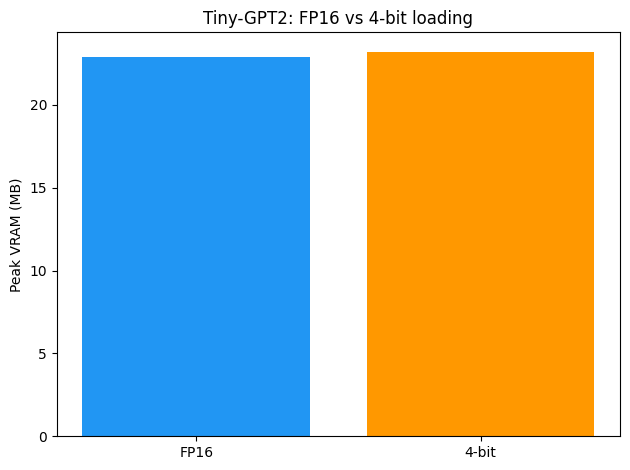

Loading weights:   0%|          | 0/29 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


KV cache stores past keys and values so decode steps reuse them. factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors


In [7]:
try:
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

    model_id = "sshleifer/tiny-gpt2"
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    prompt = "KV cache stores past keys and values so decode steps reuse them."
    inputs = tokenizer(prompt, return_tensors="pt")


    def measure_peak_vram(**load_kwargs):
        if DEVICE != "cuda":
            return None
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        model = AutoModelForCausalLM.from_pretrained(model_id, **load_kwargs)
        model_inputs = {k: v.to(model.device) for k, v in inputs.items()}
        model.generate(**model_inputs, max_new_tokens=30)
        mb = torch.cuda.max_memory_allocated() / 1e6
        del model
        torch.cuda.empty_cache()
        return mb


    fp16_mb = measure_peak_vram(torch_dtype=torch.float16, device_map="auto")
    print(f"FP16 peak VRAM: {fp16_mb:.0f} MB" if fp16_mb else "FP16 VRAM: CPU mode (skipped)")

    bnb = BitsAndBytesConfig(load_in_4bit=True)
    fourbit_mb = measure_peak_vram(quantization_config=bnb, device_map="auto")
    print(f"4-bit peak VRAM: {fourbit_mb:.0f} MB" if fourbit_mb else "4-bit VRAM: CPU mode (skipped)")

    if fp16_mb and fourbit_mb:
        reduction = 100 * (1 - fourbit_mb / fp16_mb)
        print(f"VRAM reduction (4-bit vs FP16): {reduction:.1f}%")
        plt.bar(["FP16", "4-bit"], [fp16_mb, fourbit_mb], color=["#2196f3", "#ff9800"])
        plt.ylabel("Peak VRAM (MB)")
        plt.title("Tiny-GPT2: FP16 vs 4-bit loading")
        plt.tight_layout()
        plt.show()

    # Quick generation demo with 4-bit model
    model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb, device_map="auto")
    out = model.generate(**{k: v.to(model.device) for k, v in inputs.items()}, max_new_tokens=40)
    print(tokenizer.decode(out[0], skip_special_tokens=True))
except Exception as exc:
    print(f"B4 demo skipped ({exc}). FP16 vs 4-bit VRAM needs CUDA + bitsandbytes.")

### 🛠️ B5. Per-channel vs per-tensor INT8

Compare schemes on the **trained fc1 weights** from B1, reporting both reconstruction error and **downstream test accuracy**.

Relative weight error | per-tensor: 0.0000 | per-channel: 0.0081
Test accuracy         | per-tensor: 0.950 | per-channel: 0.950 (FP32 ref: 0.950)


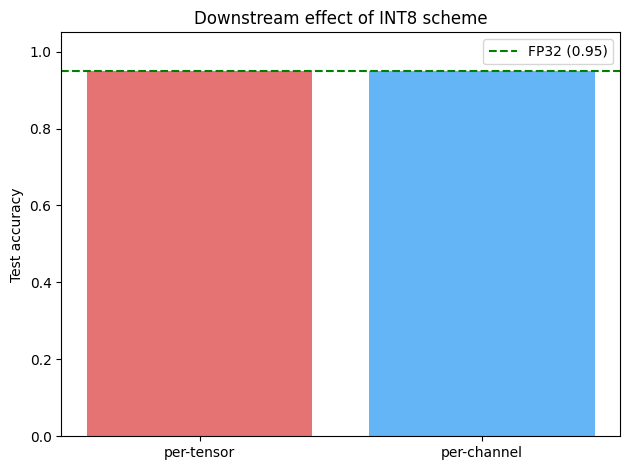

In [8]:
def quantize_per_channel(w: torch.Tensor, bits: int = 8):
    qmax = 2 ** (bits - 1) - 1
    scales = w.abs().amax(dim=1, keepdim=True).clamp(min=1e-8) / qmax
    w_q = torch.round(w / scales).clamp(-qmax, qmax)
    return w_q, scales


def apply_quantized_fc1(model: TinyMNIST, w_hat: torch.Tensor):
    with torch.no_grad():
        model.fc1.weight.copy_(w_hat.to(DEVICE))


w = quant_model.fc1.weight.data.detach().cpu()

# Per-tensor INT8
wq_t, s_t = quantize_symmetric(w)
w_hat_t = dequantize(wq_t, s_t)
apply_quantized_fc1(quant_model, w_hat_t)
acc_t = eval_accuracy(quant_model, test_loader)
err_t = (w - w_hat_t).norm() / w.norm()

# Per-channel INT8
wq_c, s_c = quantize_per_channel(w)
w_hat_c = (wq_c * s_c)
apply_quantized_fc1(quant_model, w_hat_c)
acc_c = eval_accuracy(quant_model, test_loader)
err_c = (w - w_hat_c).norm() / w.norm()

print(f"Relative weight error | per-tensor: {err_t:.4f} | per-channel: {err_c:.4f}")
print(f"Test accuracy         | per-tensor: {acc_t:.3f} | per-channel: {acc_c:.3f} (FP32 ref: {fp32_acc:.3f})")

plt.bar(["per-tensor", "per-channel"], [acc_t, acc_c], color=["#e57373", "#64b5f6"])
plt.axhline(fp32_acc, color="green", linestyle="--", label=f"FP32 ({fp32_acc:.2f})")
plt.ylim(0, 1.05)
plt.ylabel("Test accuracy")
plt.title("Downstream effect of INT8 scheme")
plt.legend()
plt.tight_layout()
plt.show()

### 🛠️ B6. Prefill vs decode timing

 LLM inference splits into **prefill** (process the full prompt in parallel) and **decode** (generate one token at a time with KV cache). Decode is usually **memory-bound**; profiling both phases reveals the bottleneck from the lecture.

In [9]:
try:
    from transformers import AutoModelForCausalLM, AutoTokenizer

    model_id = "sshleifer/tiny-gpt2"
    tok = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(model_id)
    model.eval()
    prompt = "Prefill " * 50
    inputs = tok(prompt, return_tensors="pt")

    t0 = time.perf_counter()
    with torch.no_grad():
        model(**inputs)
    prefill_ms = (time.perf_counter() - t0) * 1000

    past = None
    t0 = time.perf_counter()
    inp = inputs["input_ids"][:, :1]
    for _ in range(20):
        with torch.no_grad():
            out = model(input_ids=inp, past_key_values=past, use_cache=True)
        past = out.past_key_values
        inp = out.logits[:, -1:].argmax(-1)
    decode_ms = (time.perf_counter() - t0) * 1000
    print(f"Prefill: {prefill_ms:.1f} ms | 20 decode steps: {decode_ms:.1f} ms ({decode_ms/20:.1f} ms/step)")
except Exception as exc:
    print(f"Prefill/decode demo skipped ({exc}). Per-channel quant comparison completed above.")

Loading weights:   0%|          | 0/29 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Prefill: 157.0 ms | 20 decode steps: 162.8 ms (8.1 ms/step)


#### 📊 Summary table

After running all cells, you should see:

| Experiment | What to compare |
|------------|-----------------|
| B1 INT8 | FP32 vs dequantized **test accuracy** on trained MNIST layer |
| B2 latency | **FP32 vs FP16 vs INT8** bar chart (ms/forward) |
| B3 distillation | **Teacher vs student baseline vs distilled student** accuracy |
| B4 VRAM | **FP16 vs 4-bit** peak MB on tiny-gpt2 |
| B5 schemes | **Per-tensor vs per-channel** weight error and accuracy |
| B6 timing | Prefill vs decode ms/step |